# Quantum Approximate Optimization Algorithm (QAOA)

This notebook demonstrates the **Quantum Approximate Optimization Algorithm (QAOA)** using PennyLane.  

QAOA is a variational algorithm designed to **approximately solve combinatorial optimization problems**, such as Max-Cut.  

We will:
1. Define a small graph
2. Encode the Max-Cut problem into a Hamiltonian
3. Construct the QAOA ansatz
4. Optimize the parameters
5. Evaluate the approximate solution


In [1]:
import pennylane as qml
from pennylane import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(0)

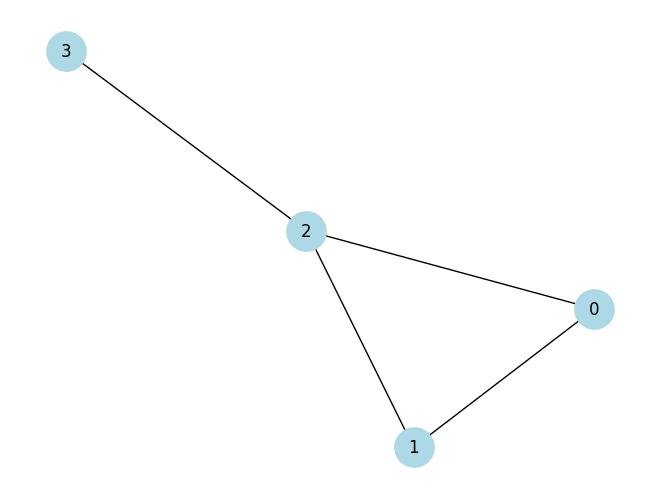

In [2]:
# Simple 4-node graph
edges = [(0, 1), (0, 2), (1, 2), (2, 3)]
G = nx.Graph()
G.add_edges_from(edges)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=800)
plt.show()

In [3]:
# Max-Cut cost Hamiltonian
n_qubits = len(G.nodes)
wires = list(range(n_qubits))


def maxcut_cost_layer(gamma):
    for i, j in G.edges:
        qml.CNOT(wires=[i, j])
        qml.RZ(2 * gamma, wires=j)
        qml.CNOT(wires=[i, j])


def qaoa_layer(gamma, beta):
    # Problem Hamiltonian
    maxcut_cost_layer(gamma)
    # Mixer Hamiltonian
    for i in range(n_qubits):
        qml.RX(2 * beta, wires=i)


# Define device and QNode
dev = qml.device("default.qubit", wires=n_qubits, shots=1000)


@qml.qnode(dev)
def qaoa_circuit(params):
    gammas = params[:p]
    betas = params[p:]
    # Initialize in equal superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for gamma, beta in zip(gammas, betas):
        qaoa_layer(gamma, beta)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


# Cost function: expected value of the Max-Cut Hamiltonian
def cost_fn(params):
    params[:p]
    params[p:]
    # Build QAOA circuit
    dev_state = qaoa_circuit(params)
    cost = 0
    # Compute expected Max-Cut value
    for i, j in G.edges:
        cost += 0.25 * (1 - dev_state[i] * dev_state[j])
    return cost

In [4]:
# Depth of QAOA
p = 2

# Random initialization
params = 0.01 * np.random.randn(2 * p, requires_grad=True)

# Optimizer
opt = qml.GradientDescentOptimizer(stepsize=0.4)
steps = 50

for i in range(steps):
    params, cost_val = opt.step_and_cost(cost_fn, params)
    if (i + 1) % 10 == 0:
        print(f"Step {i+1}: cost = {cost_val:.4f}")

Step 10: cost = 1.0001
Step 20: cost = 1.0000
Step 30: cost = 1.0003
Step 40: cost = 0.9997
Step 50: cost = 1.0000


In [5]:
# Sample bitstrings from optimized circuit
@qml.qnode(dev)
def qaoa_sample(params):
    gammas = params[:p]
    betas = params[p:]
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for gamma, beta in zip(gammas, betas):
        qaoa_layer(gamma, beta)
    # Sample all qubits
    return [qml.sample(qml.PauliZ(wires=i)) for i in range(n_qubits)]


samples = np.array(qaoa_sample(params)).T  # shape: (shots, n_qubits)

# Convert from ±1 to 0/1
samples_bin = ((1 - samples) / 2).tolist()  # ±1 → 0/1
print("Sampled solutions:", samples_bin)


# Evaluate Max-Cut
def maxcut_value(bitstring):
    return sum(1 for i, j in G.edges if bitstring[i] != bitstring[j])


cut_values = [maxcut_value(b) for b in samples_bin]
print("Max-Cut values of sampled solutions:", cut_values)
print("Best Max-Cut found:", max(cut_values))

Sampled solutions: [[1.0, 0.0, 1.0, 1.0], [0.0, 1.0, 0.0, 1.0], [0.0, 0.0, 0.0, 1.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [0.0, 1.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 0.0, 1.0], [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 0.0], [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 1.0, 0.0, 0.0], [1.0, 0.0, 0.0, 1.0], [1.0, 1.0, 1.0, 0.0], [1.0, 1.0, 1.0, 0.0], [1.0, 1.0, 1.0, 0.0], [1.0, 1.0, 1.0, 0.0], [1.0, 0.0, 1.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0], [1.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 1.0], [0.0, 1.0, 0.0, 1.0], [1.0, 1.0, 0.0, 1.0], [0.0, 0.0, 0.0, 0.0], [0.0, 1.0, 1.0, 0.0], [1.0, 0.0, 0.0, 1.0], [0.0, 1.0, 1.0, 0.0], [1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 1.0, 1.0], [1.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [1.0, 1.0, 0.0, 1.0], [1.0, 0.0, 0

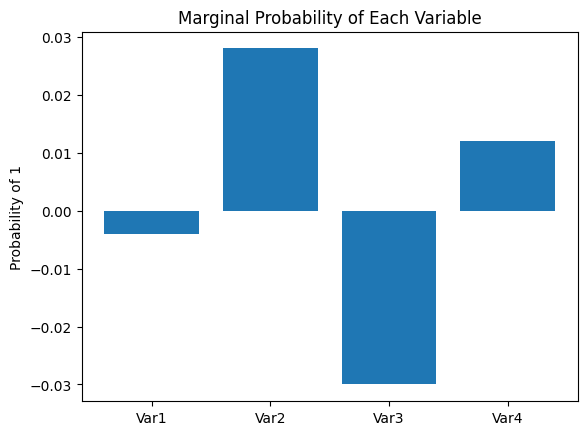

In [11]:
probabilities = samples.mean(axis=0)

plt.bar(range(1, 5), probabilities)
plt.xticks(range(1, 5), ["Var1", "Var2", "Var3", "Var4"])
plt.ylabel("Probability of 1")
plt.title("Marginal Probability of Each Variable")
plt.show()